# ORAS5 + ERA5 ConvLSTM: Iarla-style one-shot annual forecasting

This notebook loads the previously cached monthly ORAS5/ERA5 tensor and trains a
**direct multi-output ConvLSTM**:

\[
$\text{12 observed months} \longrightarrow \text{next 12 months in one forward pass}.$
\]

It does **not** feed any predicted month back into the model. For the five-year
1982–1986 comparison, each calendar year is an independent one-shot forecast
initialized from the preceding 12 **observed** months. This is therefore a
rolling annual one-shot evaluation, not a free-running five-year forecast.

## 1. Imports and reproducibility

In [1]:
from pathlib import Path
import json
import pickle
import random
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input, ConvLSTM2D, BatchNormalization, Conv2D, Reshape, Permute
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)

warnings.filterwarnings("ignore", category=RuntimeWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Available GPUs: []


## 2. Configuration

In [2]:
DATA_ROOT = Path(r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets")
CACHE_PATH = (
    DATA_ROOT / "Processed" /
    "oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc"
)
OUTPUT_DIR = DATA_ROOT / "Processed" / "Iarla_OneShot_12Month"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LOOKBACK = 12
HORIZON = 12

VALIDATION_START = pd.Timestamp("1977-01-01")
TEST_START = pd.Timestamp("1982-01-01")
TEST_END = pd.Timestamp("1986-12-01")

EPOCHS = 50
BATCH_SIZE = 2
LEARNING_RATE = 1e-3
PRIMARY_FEATURE = "sst"

MODEL_PATH = OUTPUT_DIR / "best_iarla_oneshot_convlstm.keras"
SCALER_PATH = OUTPUT_DIR / "iarla_oneshot_scaler.pkl"
HISTORY_PATH = OUTPUT_DIR / "iarla_oneshot_history.json"

print("Tensor:", CACHE_PATH)
print("Outputs:", OUTPUT_DIR)

Tensor: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc
Outputs: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month


## 3. Load and inspect the cached tensor

In [3]:
if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Cached tensor not found:\n{CACHE_PATH}\n"
        "Check the path or create the combined tensor first."
    )

ds = xr.open_dataset(CACHE_PATH, engine="h5netcdf")
if "climate" in ds.data_vars:
    combined_monthly = ds["climate"].load()
elif len(ds.data_vars) == 1:
    combined_monthly = ds[next(iter(ds.data_vars))].load()
else:
    raise ValueError(f"Could not identify tensor variable: {list(ds.data_vars)}")
ds.close()

combined_monthly = (
    combined_monthly
    .sortby("time")
    .transpose("time", "feature", "lat", "lon")
    .where(np.abs(combined_monthly) < 1e10)
    .astype(np.float32)
)

candidate_features = combined_monthly.feature.values.astype(str).tolist()
feature_report = []
retained_features = []

train_time_mask_da = combined_monthly.time.values < np.datetime64(VALIDATION_START)
for name in candidate_features:
    values = combined_monthly.sel(feature=name).values
    train_values = values[train_time_mask_da]
    finite = np.isfinite(values)
    train_std = np.nanstd(train_values)
    feature_report.append({
        "feature": name,
        "finite_fraction": float(finite.mean()),
        "training_std": float(train_std) if np.isfinite(train_std) else np.nan,
    })
    if finite.any() and np.isfinite(train_std) and train_std > 1e-8:
        retained_features.append(name)

feature_quality_df = pd.DataFrame(feature_report)
display(feature_quality_df)

removed_features = [f for f in candidate_features if f not in retained_features]
print("Removed empty/constant features:", removed_features)

combined_monthly = combined_monthly.sel(feature=retained_features)
features = retained_features
times = pd.DatetimeIndex(pd.to_datetime(combined_monthly.time.values))
lats = combined_monthly.lat.values
lons = combined_monthly.lon.values

raw_data = combined_monthly.transpose(
    "time", "lat", "lon", "feature"
).values.astype(np.float32)

print("Shape:", raw_data.shape)
print("Features:", features)
print("Range:", times.min().strftime("%Y-%m"), "to", times.max().strftime("%Y-%m"))
print("Grid:", len(lats), "×", len(lons))

,feature,finite_fraction,training_std
0,sst,1.0,4.128275
1,salinity,1.0,0.687953
2,thetao,1.0,3.708173
3,qnet,1.0,185.459488
4,u_current,1.0,0.082924
5,v_current,1.0,0.081375
6,era5_sst,1.0,4.137603
7,era5_u10,0.0,NaN
8,era5_v10,0.0,NaN
9,era5_runoff,1.0,0.000000


Removed empty/constant features: ['era5_u10', 'era5_v10', 'era5_runoff', 'era5_d2m', 'era5_skt', 'era5_stl2', 'era5_swvl1']
Shape: (731, 41, 41, 7)
Features: ['sst', 'salinity', 'thetao', 'qnet', 'u_current', 'v_current', 'era5_sst']
Range: 1958-01 to 2018-12
Grid: 41 × 41


## 4. Calendar integrity

A block is accepted only when all 24 months (12 inputs plus 12 targets) are
consecutive. Need to fix weird 1979-02 file.

In [4]:
expected_months = pd.date_range(times.min(), times.max(), freq="MS")
missing_months = expected_months.difference(times)
print("Missing complete months:", len(missing_months))
print([d.strftime("%Y-%m") for d in missing_months])

if PRIMARY_FEATURE not in features:
    raise ValueError(f"{PRIMARY_FEATURE!r} is not in retained features: {features}")

Missing complete months: 1
['1979-02']


## 5. Training-only imputation and scaling

In [5]:
train_fit_mask = times < VALIDATION_START
if not train_fit_mask.any():
    raise ValueError("No months are available for fitting preprocessing.")

n_time, n_lat, n_lon, n_features = raw_data.shape
train_data = raw_data[train_fit_mask]
train_times = times[train_fit_mask]

monthly_climatology = np.full((12, n_lat, n_lon, n_features), np.nan, np.float32)
for month in range(1, 13):
    month_values = train_data[train_times.month == month]
    if len(month_values):
        monthly_climatology[month - 1] = np.nanmean(month_values, axis=0)

cell_mean = np.nanmean(train_data, axis=0)
feature_median = np.array([
    np.nanmedian(train_data[..., i]) for i in range(n_features)
], dtype=np.float32)

imputed_data = raw_data.copy()
for t, timestamp in enumerate(times):
    field = imputed_data[t]
    missing = ~np.isfinite(field)
    if missing.any():
        clim = monthly_climatology[timestamp.month - 1]
        field[missing] = clim[missing]
        missing = ~np.isfinite(field)
        field[missing] = cell_mean[missing]
        missing = ~np.isfinite(field)
        for i in range(n_features):
            feature_missing = missing[..., i]
            field[..., i][feature_missing] = feature_median[i]
    imputed_data[t] = field

if not np.isfinite(imputed_data).all():
    raise ValueError("Non-finite values remain after imputation.")

scaling_mean = np.mean(imputed_data[train_fit_mask], axis=(0, 1, 2))
scaling_std = np.std(imputed_data[train_fit_mask], axis=(0, 1, 2))
scaling_std = np.where(scaling_std < 1e-8, 1.0, scaling_std)
scaled_data = ((imputed_data - scaling_mean) / scaling_std).astype(np.float32)

scaler = {
    "features": features,
    "mean": scaling_mean,
    "std": scaling_std,
    "monthly_climatology": monthly_climatology,
    "cell_mean": cell_mean,
    "feature_median": feature_median,
}
with open(SCALER_PATH, "wb") as handle:
    pickle.dump(scaler, handle)

def inverse_scale(array):
    return array * scaling_std + scaling_mean

display(pd.DataFrame({
    "feature": features,
    "training_mean": scaling_mean,
    "training_std": scaling_std,
}))

,feature,training_mean,training_std
0,sst,20.633944,4.128009
1,salinity,36.409763,0.688068
2,thetao,19.737841,3.707966
3,qnet,-28.248745,185.448532
4,u_current,0.023949,0.082915
5,v_current,-0.005960,0.081360
6,era5_sst,20.586727,4.137372


## 6. Construct consecutive 12→12 blocks

In [6]:
def is_consecutive(months):
    expected = pd.date_range(months[0], periods=len(months), freq="MS")
    return pd.DatetimeIndex(months).equals(expected)

X_all, y_all, target_starts, target_ends = [], [], [], []
required = LOOKBACK + HORIZON

for start in range(0, len(times) - required + 1):
    block_times = times[start:start + required]
    if not is_consecutive(block_times):
        continue
    input_end = start + LOOKBACK
    target_end = input_end + HORIZON
    X_all.append(scaled_data[start:input_end])
    y_all.append(scaled_data[input_end:target_end])
    target_starts.append(times[input_end])
    target_ends.append(times[target_end - 1])

X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.float32)
target_starts = pd.DatetimeIndex(target_starts)
target_ends = pd.DatetimeIndex(target_ends)

train_mask = target_ends < VALIDATION_START
validation_mask = (
    (target_starts >= VALIDATION_START)
    & (target_ends < TEST_START)
)
test_mask = (
    (target_starts >= TEST_START)
    & (target_ends <= TEST_END)
)

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[validation_mask], y_all[validation_mask]
X_test_all, y_test_all = X_all[test_mask], y_all[test_mask]
test_target_starts_all = target_starts[test_mask]
test_target_ends_all = target_ends[test_mask]

print("All valid blocks:", len(X_all))
print("Training blocks:", X_train.shape, y_train.shape)
print("Validation blocks:", X_val.shape, y_val.shape)
print("All rolling test blocks:", X_test_all.shape, y_test_all.shape)
print("Training targets:", target_starts[train_mask].min(), "to", target_ends[train_mask].max())
print("Validation targets:", target_starts[validation_mask].min(), "to", target_ends[validation_mask].max())

All valid blocks: 685
Training blocks: (205, 12, 41, 41, 7) (205, 12, 41, 41, 7)
Validation blocks: (25, 12, 41, 41, 7) (25, 12, 41, 41, 7)
All rolling test blocks: (49, 12, 41, 41, 7) (49, 12, 41, 41, 7)
Training targets: 1959-01-01 00:00:00 to 1976-12-01 00:00:00
Validation targets: 1977-01-01 00:00:00 to 1981-12-01 00:00:00


## 7. ConvLSTM direct multi-output model

In [7]:
tf.keras.backend.clear_session()

input_shape = (LOOKBACK, n_lat, n_lon, n_features)
inputs = Input(shape=input_shape, name="observed_12_months")

x = ConvLSTM2D(
    filters=32, kernel_size=(3, 3), padding="same",
    return_sequences=True, activation="tanh",
    recurrent_activation="sigmoid", name="convlstm_1"
)(inputs)
x = BatchNormalization(name="batchnorm_1")(x)

x = ConvLSTM2D(
    filters=32, kernel_size=(3, 3), padding="same",
    return_sequences=True, activation="tanh",
    recurrent_activation="sigmoid", name="convlstm_2"
)(x)
x = BatchNormalization(name="batchnorm_2")(x)

x = ConvLSTM2D(
    filters=16, kernel_size=(3, 3), padding="same",
    return_sequences=False, activation="tanh",
    recurrent_activation="sigmoid", name="convlstm_encoder"
)(x)
x = BatchNormalization(name="batchnorm_encoder")(x)

x = Conv2D(
    filters=HORIZON * n_features,
    kernel_size=(1, 1),
    padding="same",
    activation="linear",
    name="direct_12_month_head",
)(x)


x = Reshape((n_lat, n_lon, HORIZON, n_features), name="split_leads")(x)
outputs = Permute((3, 1, 2, 4), name="forecast_12_months")(x)

model = Model(inputs=inputs, outputs=outputs, name="Iarla_OneShot_ConvLSTM")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="mse",
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
)
model.summary()

Model: "Iarla_OneShot_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ observed_12_months (InputLayer)      │ (None, 12, 41, 41, 7)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ convlstm_1 (ConvLSTM2D)              │ (None, 12, 41, 41, 32)      │          45,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batchnorm_1 (BatchNormalization)     │ (None, 12, 41, 41, 32)      │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ convlstm_2 (ConvLSTM2D)              │ (None, 12, 41, 41, 32)      │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batchnorm_2 (BatchNormalization)     │ (None, 12, 41, 41, 32)      │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ convlstm_encoder (ConvLSTM2D)        │ (None, 41, 41, 16)          │          27,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batchnorm_encoder                    │ (None, 41, 41, 16)          │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ direct_12_month_head (Conv2D)        │ (None, 41, 41, 84)          │           1,428 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ split_leads (Reshape)                │ (None, 41, 41, 12, 7)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ forecast_12_months (Permute)         │ (None, 12, 41, 41, 7)       │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 148,372 (579.58 KB)

 Trainable params: 148,212 (578.95 KB)

 Non-trainable params: 160 (640.00 B)

## 8. Train

In [8]:
callbacks = [
    ModelCheckpoint(
        MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4,
        min_lr=1e-6, verbose=1
    ),
    EarlyStopping(
        monitor="val_loss", patience=8,
        restore_best_weights=True, verbose=1
    ),
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    callbacks=callbacks,
    verbose=1,
)

history_serializable = {
    key: [float(v) for v in values]
    for key, values in history.history.items()
}
HISTORY_PATH.write_text(json.dumps(history_serializable, indent=2))
model = tf.keras.models.load_model(MODEL_PATH)
print("Best epoch:", int(np.argmin(history.history["val_loss"]) + 1))
print("Best validation MSE:", float(np.min(history.history["val_loss"])))

Epoch 1/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.8867 - mae: 0.6487
Epoch 1: val_loss improved from None to 0.71016, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month\best_iarla_oneshot_convlstm.keras

Epoch 1: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month\best_iarla_oneshot_convlstm.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 52s 353ms/step - loss: 0.7181 - mae: 0.5712 - val_loss: 0.7102 - val_mae: 0.5761 - learning_rate: 0.0010
Epoch 2/50
103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - loss: 0.4992 - mae: 0.4709
Epoch 2: val_loss improved from 0.71016 to 0.55092, saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month\best_iarla_oneshot_convlstm.keras

Epoch 2: finished saving model to C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month\best_iarla_oneshot_convlstm.keras
103/103 ━━━━━━━━━━━━━━━━━━━━ 35s 

## 9. Training and validation learning curves

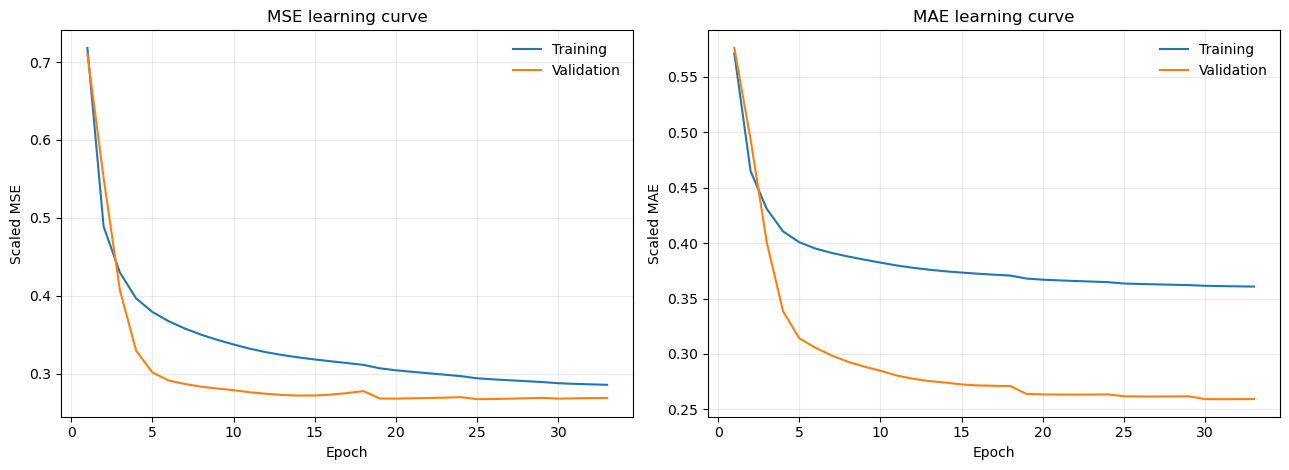

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
epochs_run = np.arange(1, len(history.history["loss"]) + 1)

axes[0].plot(epochs_run, history.history["loss"], label="Training")
axes[0].plot(epochs_run, history.history["val_loss"], label="Validation")
axes[0].set(title="MSE learning curve", xlabel="Epoch", ylabel="Scaled MSE")
axes[0].grid(alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(epochs_run, history.history["mae"], label="Training")
axes[1].plot(epochs_run, history.history["val_mae"], label="Validation")
axes[1].set(title="MAE learning curve", xlabel="Epoch", ylabel="Scaled MAE")
axes[1].grid(alpha=0.25)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

## 10. Five independent annual one-shot forecasts

In [10]:
desired_starts = pd.DatetimeIndex([
    pd.Timestamp(year=year, month=1, day=1)
    for year in range(TEST_START.year, TEST_END.year + 1)
])
annual_indices = []
for desired in desired_starts:
    matches = np.flatnonzero(test_target_starts_all == desired)
    if len(matches) != 1:
        raise ValueError(f"Expected one block beginning {desired:%Y-%m}, found {len(matches)}")
    annual_indices.append(matches[0])

X_test = X_test_all[annual_indices]
y_test_scaled = y_test_all[annual_indices]
block_starts = test_target_starts_all[annual_indices]

y_pred_scaled = model.predict(X_test, batch_size=1, verbose=1)
y_test_true_blocks = inverse_scale(y_test_scaled)
y_test_pred_blocks = inverse_scale(y_pred_scaled)

y_test_true = y_test_true_blocks.reshape(-1, n_lat, n_lon, n_features)
y_test_pred = y_test_pred_blocks.reshape(-1, n_lat, n_lon, n_features)
test_times = pd.date_range(TEST_START, TEST_END, freq="MS")

print("Input blocks:", X_test.shape)
print("One-shot output blocks:", y_test_pred_blocks.shape)
print("Concatenated comparison:", y_test_pred.shape)
print("Test months:", test_times.min(), "to", test_times.max())

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step
Input blocks: (5, 12, 41, 41, 7)
One-shot output blocks: (5, 12, 41, 41, 7)
Concatenated comparison: (60, 41, 41, 7)
Test months: 1982-01-01 00:00:00 to 1986-12-01 00:00:00


## 11. Metric helpers

In [11]:
def metric_row(actual, predicted, label=None):
    valid = np.isfinite(actual) & np.isfinite(predicted)
    a = np.asarray(actual)[valid].ravel()
    p = np.asarray(predicted)[valid].ravel()
    if len(a) == 0:
        return {"label": label, "n": 0}
    error = p - a
    correlation = pearsonr(a, p).statistic if np.std(a) > 0 and np.std(p) > 0 else np.nan
    return {
        "label": label,
        "n": int(len(a)),
        "MAE": float(mean_absolute_error(a, p)),
        "RMSE": float(np.sqrt(mean_squared_error(a, p))),
        "R2": float(r2_score(a, p)) if np.var(a) > 0 else np.nan,
        "bias_predicted_minus_actual": float(np.mean(error)),
        "Pearson_r": float(correlation),
    }

overall_rows = []
for i, feature in enumerate(features):
    overall_rows.append(metric_row(
        y_test_true[..., i], y_test_pred[..., i], label=feature
    ))
overall_metrics_df = pd.DataFrame(overall_rows).rename(columns={"label": "feature"})
display(overall_metrics_df)

,feature,n,MAE,RMSE,R2,bias_predicted_minus_actual,Pearson_r
0,sst,100860,0.691196,0.939140,0.945510,0.078439,0.972836
1,salinity,100860,0.109064,0.153765,0.945871,-0.049564,0.976619
2,thetao,100860,0.526722,0.742778,0.957891,-0.017840,0.979000
3,qnet,100860,48.448982,86.734430,0.740828,2.484450,0.862061
4,u_current,100860,0.040132,0.072691,0.236235,0.002026,0.499074
5,v_current,100860,0.036314,0.068116,0.252395,0.003426,0.511907
6,era5_sst,100860,0.720842,0.994088,0.941794,0.013006,0.970466


## 12. Fair baselines

In [12]:
X_test_unscaled = inverse_scale(X_test)
persistence_blocks = np.repeat(
    X_test_unscaled[:, -1:, ...], HORIZON, axis=1
)
seasonal_persistence_blocks = X_test_unscaled.copy()

baseline_rows = []
for i, feature in enumerate(features):
    for model_name, predictions in [
        ("ConvLSTM one-shot", y_test_pred_blocks),
        ("Persistence", persistence_blocks),
        ("Seasonal persistence", seasonal_persistence_blocks),
    ]:
        row = metric_row(
            y_test_true_blocks[..., i], predictions[..., i],
            label=model_name
        )
        row["feature"] = feature
        baseline_rows.append(row)

baseline_metrics_df = pd.DataFrame(baseline_rows).drop(columns="label").assign(
    model=[r["label"] for r in baseline_rows]
)
baseline_metrics_df = baseline_metrics_df[
    ["feature", "model", "n", "MAE", "RMSE", "R2",
     "bias_predicted_minus_actual", "Pearson_r"]
]
display(baseline_metrics_df)

sst_baselines = baseline_metrics_df[
    baseline_metrics_df["feature"] == PRIMARY_FEATURE
].set_index("model")
model_rmse = sst_baselines.loc["ConvLSTM one-shot", "RMSE"]
seasonal_rmse = sst_baselines.loc["Seasonal persistence", "RMSE"]
print("SST skill versus seasonal persistence:", 1 - model_rmse / seasonal_rmse)

,feature,model,n,MAE,RMSE,R2,bias_predicted_minus_actual,Pearson_r
0,sst,ConvLSTM one-shot,100860,0.691196,0.939140,0.945510,0.078439,0.972836
1,sst,Persistence,100860,2.395073,3.038636,0.429554,-1.208913,0.731324
2,sst,Seasonal persistence,100860,0.635181,0.853632,0.954981,-0.012408,0.977275
3,salinity,ConvLSTM one-shot,100860,0.109064,0.153765,0.945871,-0.049564,0.976619
4,salinity,Persistence,100860,0.109752,0.165214,0.937510,0.017570,0.969178
5,salinity,Seasonal persistence,100860,0.103836,0.150837,0.947912,0.000671,0.974381
6,thetao,ConvLSTM one-shot,100860,0.526722,0.742778,0.957891,-0.017840,0.979000
7,thetao,Persistence,100860,1.746928,2.136162,0.651723,-0.523070,0.827120
8,thetao,Seasonal persistence,100860,0.537572,0.747397,0.957366,-0.003948,0.978492
9,qnet,ConvLSTM one-shot,100860,48.448982,86.734430,0.740828,2.484450,0.862061


SST skill versus seasonal persistence: -0.10017007514519483


## 13. SST metrics by forecast lead and by year

,lead_month,n,MAE,RMSE,R2,bias_predicted_minus_actual,Pearson_r
0,1,8405,0.496466,0.695162,0.958674,-0.378815,0.986543
1,2,8405,0.541906,0.788749,0.944029,-0.341037,0.982397
2,3,8405,0.451833,0.714723,0.954581,-0.252428,0.981674
3,4,8405,0.598912,0.844010,0.933645,0.287466,0.970388
4,5,8405,0.878663,1.127458,0.872208,0.712281,0.960876
5,6,8405,0.880548,1.129848,0.878066,0.605929,0.959056
6,7,8405,0.744236,0.986379,0.866897,0.027993,0.933308
7,8,8405,0.848377,1.079999,0.761660,-0.368766,0.929314
8,9,8405,0.576272,0.800507,0.902226,-0.246087,0.958846
9,10,8405,0.665600,0.915521,0.917491,0.305644,0.964386


,year,n,MAE,RMSE,R2,bias_predicted_minus_actual,Pearson_r
0,1982,20172,0.594073,0.816626,0.961425,0.127736,0.981154
1,1983,20172,0.710517,0.939221,0.937410,0.000128,0.974137
2,1984,20172,0.654520,0.883709,0.946691,0.118846,0.974499
3,1985,20172,0.800527,1.110490,0.929628,0.413104,0.969377
4,1986,20172,0.696343,0.920203,0.950896,-0.267620,0.977269


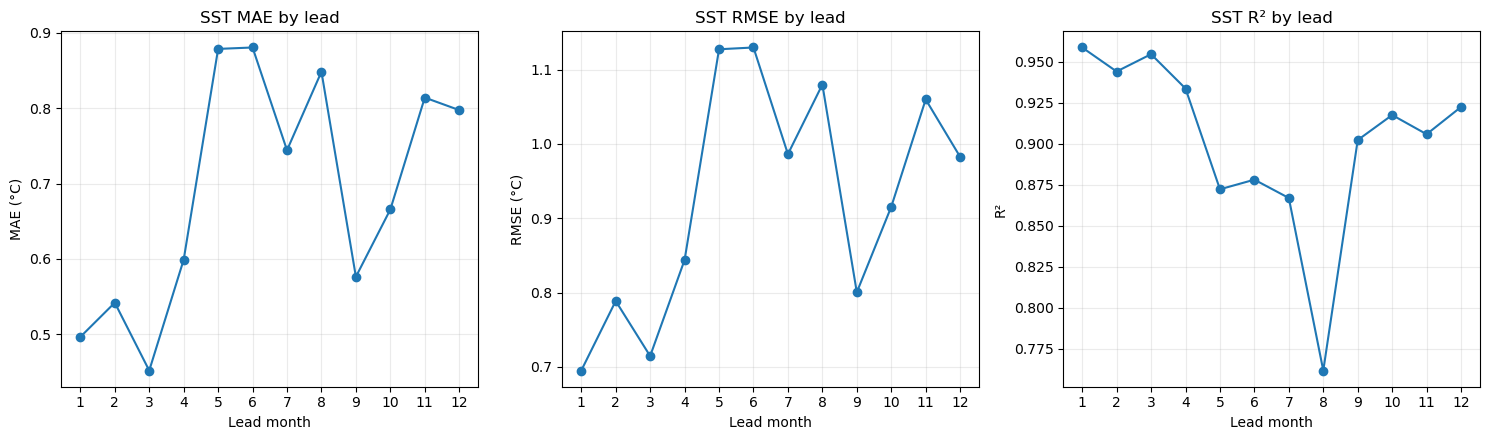

In [13]:
primary_idx = features.index(PRIMARY_FEATURE)

lead_rows = []
for lead in range(HORIZON):
    row = metric_row(
        y_test_true_blocks[:, lead, ..., primary_idx],
        y_test_pred_blocks[:, lead, ..., primary_idx],
        label=lead + 1,
    )
    lead_rows.append(row)
lead_metrics_df = pd.DataFrame(lead_rows).rename(columns={"label": "lead_month"})

year_rows = []
for block_index, year in enumerate(block_starts.year):
    row = metric_row(
        y_test_true_blocks[block_index, ..., primary_idx],
        y_test_pred_blocks[block_index, ..., primary_idx],
        label=int(year),
    )
    year_rows.append(row)
yearly_metrics_df = pd.DataFrame(year_rows).rename(columns={"label": "year"})

display(lead_metrics_df)
display(yearly_metrics_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].plot(lead_metrics_df["lead_month"], lead_metrics_df["MAE"], "-o")
axes[0].set(title="SST MAE by lead", xlabel="Lead month", ylabel="MAE (°C)")
axes[1].plot(lead_metrics_df["lead_month"], lead_metrics_df["RMSE"], "-o")
axes[1].set(title="SST RMSE by lead", xlabel="Lead month", ylabel="RMSE (°C)")
axes[2].plot(lead_metrics_df["lead_month"], lead_metrics_df["R2"], "-o")
axes[2].set(title="SST R² by lead", xlabel="Lead month", ylabel="R²")
for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 14. Cumulative one- to five-year SST metrics

In [14]:
cumulative_rows = []
for n_years in range(1, len(block_starts) + 1):
    row = metric_row(
        y_test_true_blocks[:n_years, ..., primary_idx],
        y_test_pred_blocks[:n_years, ..., primary_idx],
        label=n_years,
    )
    row["period"] = f"{block_starts[0].year}–{block_starts[n_years - 1].year}"
    cumulative_rows.append(row)

cumulative_metrics_df = pd.DataFrame(cumulative_rows).rename(
    columns={"label": "number_of_years"}
)
display(cumulative_metrics_df)

,number_of_years,n,MAE,RMSE,R2,bias_predicted_minus_actual,Pearson_r,period
0,1,20172,0.594073,0.816626,0.961425,0.127736,0.981154,1982–1982
1,2,40344,0.652295,0.880061,0.950672,0.063932,0.976067,1982–1983
2,3,60516,0.653037,0.881279,0.949407,0.082237,0.975547,1982–1984
3,4,80688,0.689909,0.943815,0.944022,0.164953,0.972861,1982–1985
4,5,100860,0.691196,0.939140,0.945510,0.078439,0.972836,1982–1986


## 15. Monthly and annual box-mean SST

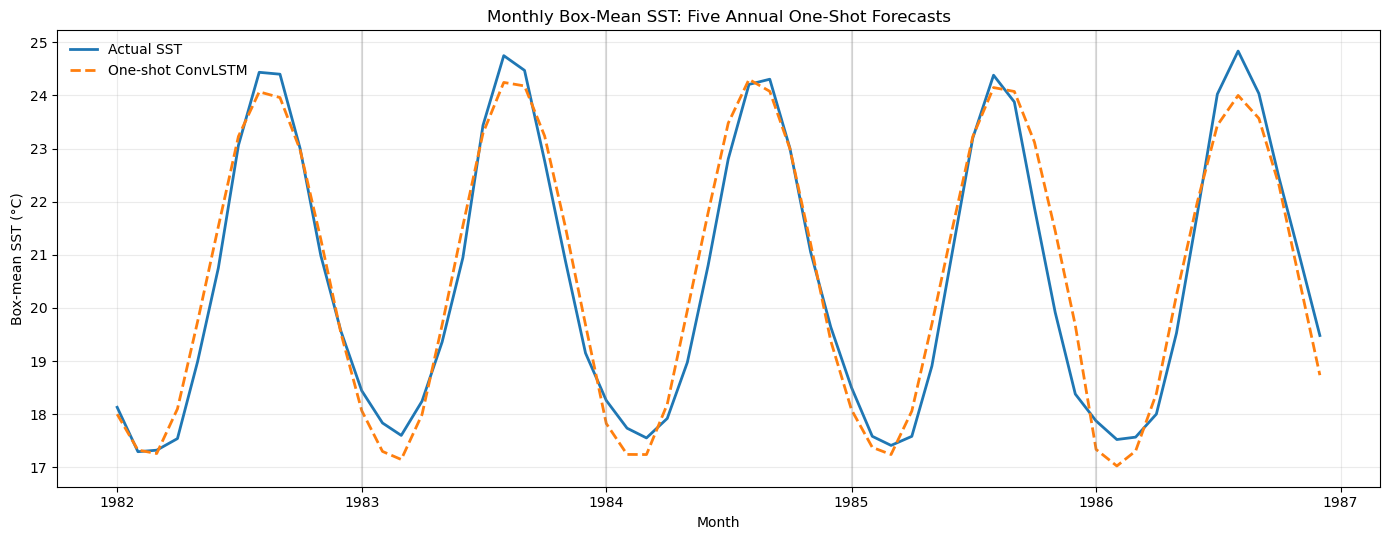

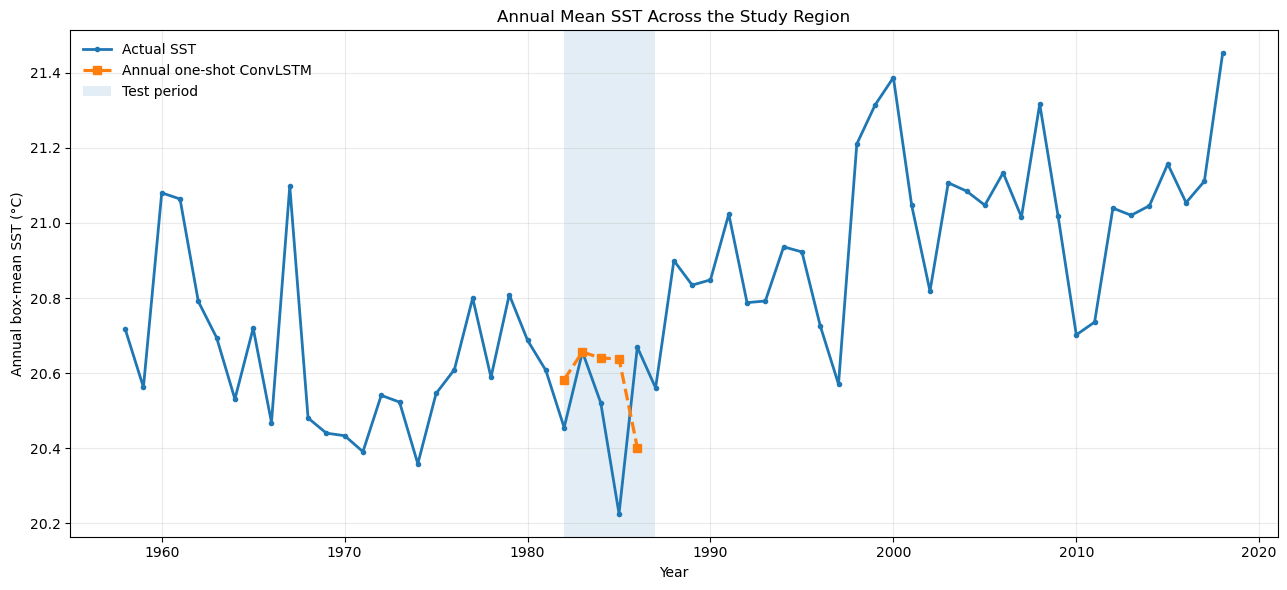

,year,predicted_mean_sst,actual_mean_sst,actual_minus_predicted
0,1982,20.582663,20.454927,-0.127735
1,1983,20.656511,20.656385,-0.000126
2,1984,20.639793,20.520947,-0.118847
3,1985,20.638468,20.225363,-0.413105
4,1986,20.401548,20.669168,0.267620


In [15]:
actual_monthly_box = np.nanmean(
    y_test_true[..., primary_idx], axis=(1, 2)
)
predicted_monthly_box = np.nanmean(
    y_test_pred[..., primary_idx], axis=(1, 2)
)

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(test_times, actual_monthly_box, label="Actual SST", linewidth=2)
ax.plot(test_times, predicted_monthly_box, "--", label="One-shot ConvLSTM", linewidth=2)
for year in range(TEST_START.year + 1, TEST_END.year + 1):
    ax.axvline(pd.Timestamp(year, 1, 1), color="grey", alpha=0.25)
ax.set(
    title="Monthly Box-Mean SST: Five Annual One-Shot Forecasts",
    xlabel="Month", ylabel="Box-mean SST (°C)"
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

full_actual_monthly = np.nanmean(raw_data[..., primary_idx], axis=(1, 2))
actual_annual_df = pd.DataFrame({
    "time": times, "actual_mean_sst": full_actual_monthly
}).assign(year=lambda d: d.time.dt.year).groupby("year", as_index=False).agg(
    actual_mean_sst=("actual_mean_sst", "mean"),
    n_months=("actual_mean_sst", "count"),
)
predicted_annual_df = pd.DataFrame({
    "time": test_times, "predicted_mean_sst": predicted_monthly_box
}).assign(year=lambda d: d.time.dt.year).groupby("year", as_index=False).agg(
    predicted_mean_sst=("predicted_mean_sst", "mean")
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    actual_annual_df["year"], actual_annual_df["actual_mean_sst"],
    "-o", markersize=3, linewidth=2, label="Actual SST"
)
ax.plot(
    predicted_annual_df["year"], predicted_annual_df["predicted_mean_sst"],
    "--s", markersize=6, linewidth=2.3, label="Annual one-shot ConvLSTM"
)
ax.axvspan(TEST_START.year, TEST_END.year + 0.99, alpha=0.13, label="Test period")
ax.set(
    title="Annual Mean SST Across the Study Region",
    xlabel="Year", ylabel="Annual box-mean SST (°C)"
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

annual_comparison_df = predicted_annual_df.merge(
    actual_annual_df[["year", "actual_mean_sst"]], on="year", how="left"
)
annual_comparison_df["actual_minus_predicted"] = (
    annual_comparison_df["actual_mean_sst"]
    - annual_comparison_df["predicted_mean_sst"]
)
display(annual_comparison_df)

## 16. Annual mean relative difference with uncertainty

,year,mean_relative_difference,standard_deviation,standard_error_of_mean,n_months
0,1982,-0.007154,0.019727,0.005695,12
1,1983,0.000360,0.023329,0.006735,12
2,1984,-0.005222,0.026473,0.007642,12
3,1985,-0.020743,0.034011,0.009818,12
4,1986,0.012434,0.023517,0.006789,12


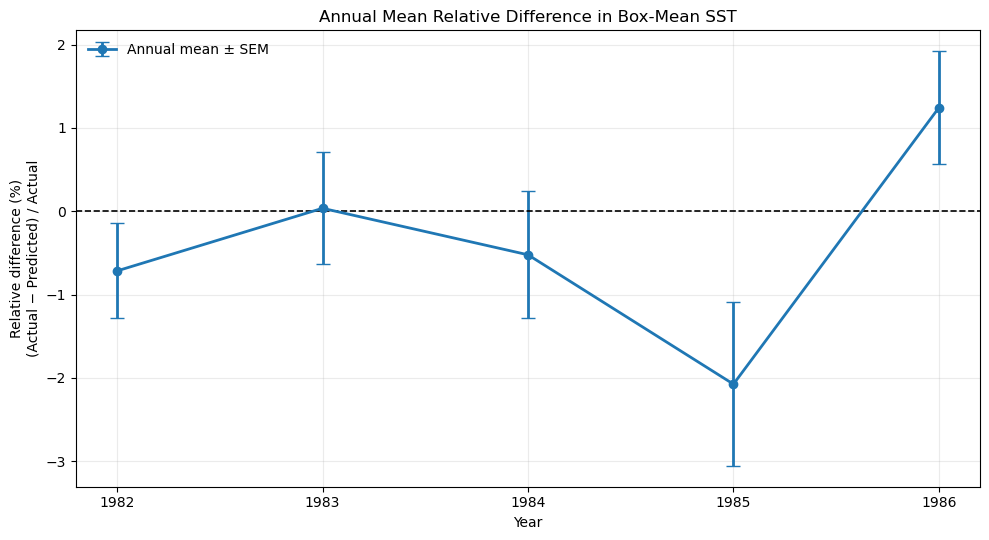

In [16]:
monthly_relative_box = (
    actual_monthly_box - predicted_monthly_box
) / actual_monthly_box

monthly_relative_df = pd.DataFrame({
    "time": test_times,
    "year": test_times.year,
    "relative_difference": monthly_relative_box,
})

relative_rows = []
for year, group in monthly_relative_df.groupby("year"):
    values = group["relative_difference"].dropna().to_numpy()
    relative_rows.append({
        "year": int(year),
        "mean_relative_difference": np.mean(values),
        "standard_deviation": np.std(values, ddof=1),
        "standard_error_of_mean": np.std(values, ddof=1) / np.sqrt(len(values)),
        "n_months": len(values),
    })
annual_relative_difference_df = pd.DataFrame(relative_rows)
display(annual_relative_difference_df)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.errorbar(
    annual_relative_difference_df["year"],
    100 * annual_relative_difference_df["mean_relative_difference"],
    yerr=100 * annual_relative_difference_df["standard_error_of_mean"],
    marker="o", linewidth=2, capsize=5,
    label="Annual mean ± SEM"
)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set(
    title="Annual Mean Relative Difference in Box-Mean SST",
    xlabel="Year",
    ylabel="Relative difference (%)\n(Actual − Predicted) / Actual",
)
ax.set_xticks(annual_relative_difference_df["year"])
ax.grid(alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 17. Annual cell-month relative-difference histograms

Each complete annual histogram contains `12 × 41 × 41 = 20,172` entries.

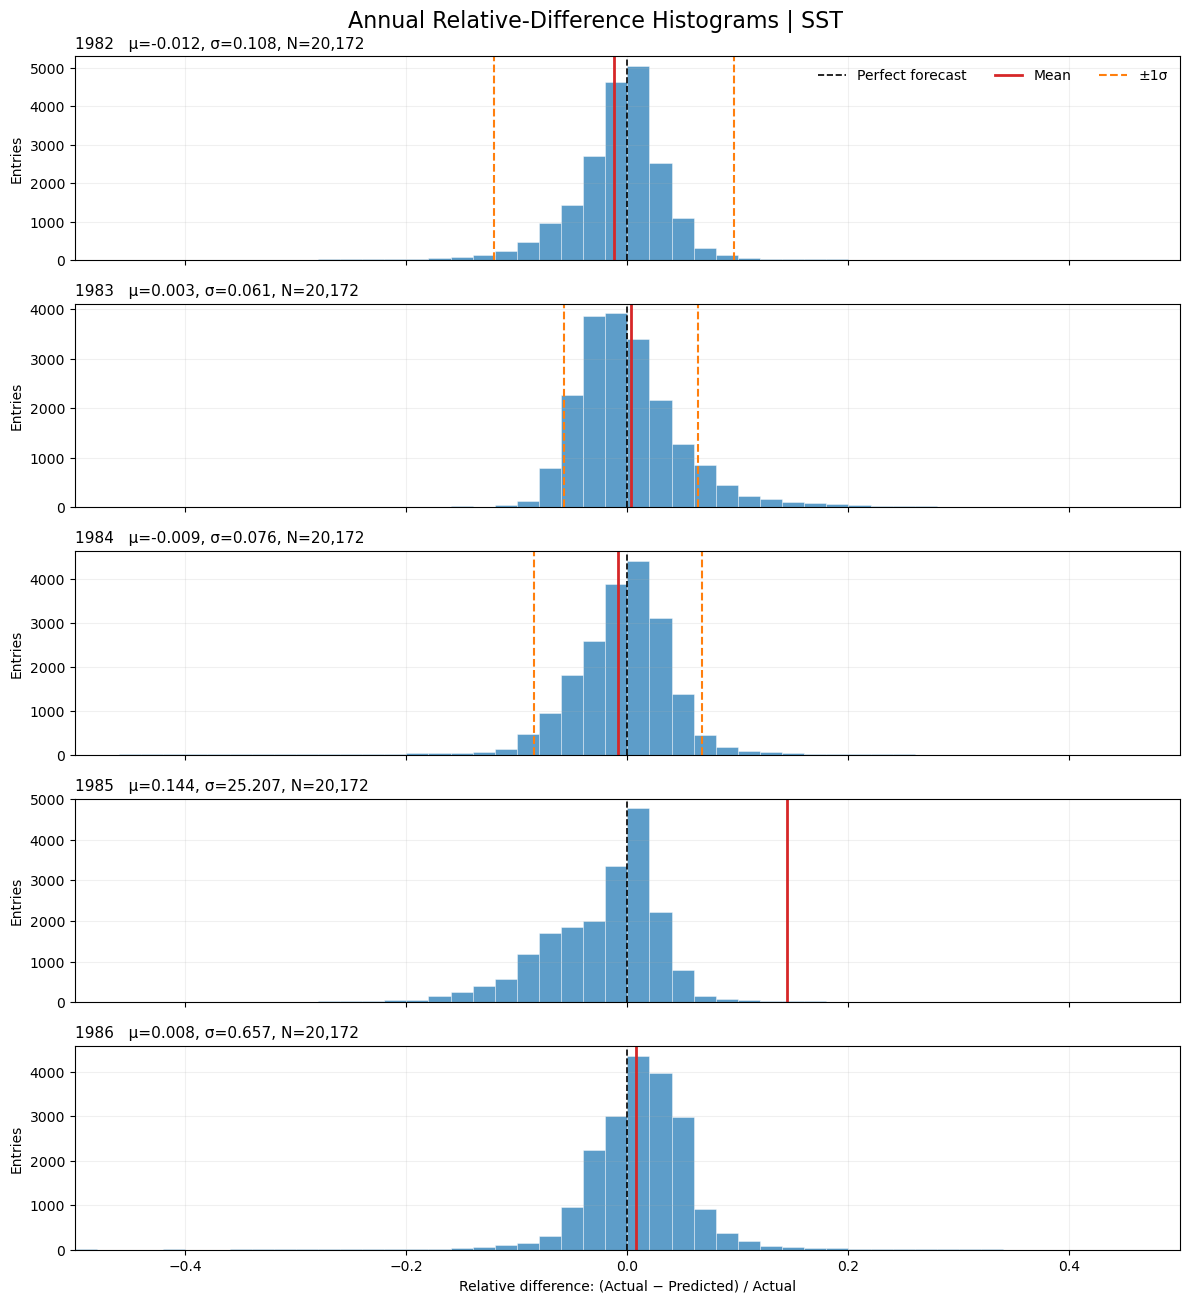

,year,mean,standard_deviation,n_entries
0,1982,-0.012151,0.108307,20172
1,1983,0.002961,0.060583,20172
2,1984,-0.008553,0.076104,20172
3,1985,0.144326,25.206793,20172
4,1986,0.008012,0.657312,20172


In [17]:
actual_sst = y_test_true[..., primary_idx]
predicted_sst = y_test_pred[..., primary_idx]
relative_grid = np.full_like(actual_sst, np.nan, dtype=np.float64)
valid = (
    np.isfinite(actual_sst) & np.isfinite(predicted_sst)
    & (np.abs(actual_sst) > 1e-6)
)
relative_grid[valid] = (
    actual_sst[valid] - predicted_sst[valid]
) / actual_sst[valid]

x_min, x_max = -0.5, 0.5
shared_bins = np.linspace(x_min, x_max, 51)
years = np.unique(test_times.year)
fig, axes = plt.subplots(
    len(years), 1, figsize=(12, 2.65 * len(years)), sharex=True
)
histogram_rows = []

for plot_index, year in enumerate(years):
    ax = axes[plot_index]
    values = relative_grid[test_times.year == year].ravel()
    values = values[np.isfinite(values)]
    mean_error = np.mean(values)
    std_error = np.std(values, ddof=1)
    histogram_rows.append({
        "year": int(year), "mean": mean_error,
        "standard_deviation": std_error, "n_entries": len(values)
    })
    ax.hist(values, bins=shared_bins, alpha=0.72, edgecolor="white", linewidth=0.4)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.2,
               label="Perfect forecast" if plot_index == 0 else None)
    ax.axvline(mean_error, color="tab:red", linewidth=2,
               label="Mean" if plot_index == 0 else None)
    ax.axvline(mean_error - std_error, color="tab:orange", linestyle="--",
               label="±1σ" if plot_index == 0 else None)
    ax.axvline(mean_error + std_error, color="tab:orange", linestyle="--")
    ax.set_xlim(x_min, x_max)
    ax.set_ylabel("Entries")
    ax.set_title(
        f"{year}   μ={mean_error:.3f}, σ={std_error:.3f}, N={len(values):,}",
        loc="left", fontsize=11
    )
    ax.grid(alpha=0.18)

axes[0].legend(frameon=False, ncol=3, loc="upper right")
axes[-1].set_xlabel("Relative difference: (Actual − Predicted) / Actual")
fig.suptitle("Annual Relative-Difference Histograms | SST", fontsize=16)
plt.tight_layout()
plt.show()

annual_histogram_summary_df = pd.DataFrame(histogram_rows)
display(annual_histogram_summary_df)

## 18. Predicted-versus-actual scatter and residual diagnostics

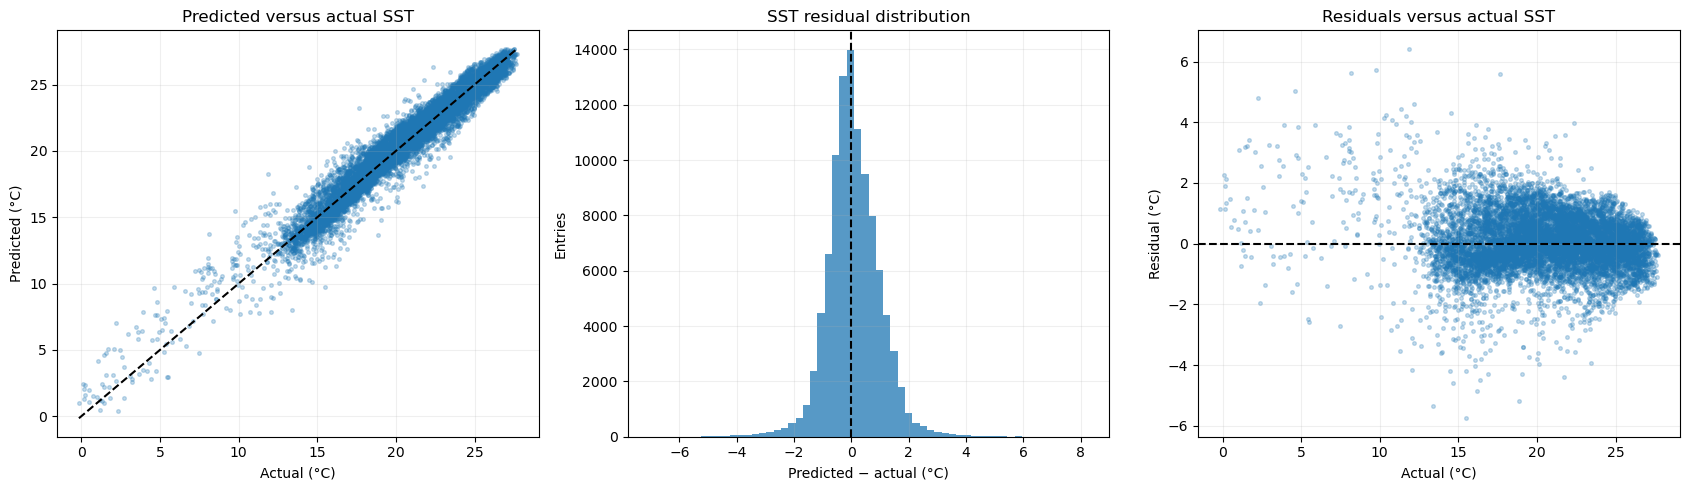

In [18]:
a = actual_sst.ravel()
p = predicted_sst.ravel()
valid = np.isfinite(a) & np.isfinite(p)
a, p = a[valid], p[valid]
rng = np.random.default_rng(SEED)
sample = rng.choice(len(a), size=min(10000, len(a)), replace=False)
residual = p - a

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].scatter(a[sample], p[sample], s=7, alpha=0.25)
limits = [min(a[sample].min(), p[sample].min()), max(a[sample].max(), p[sample].max())]
axes[0].plot(limits, limits, "k--")
axes[0].set(title="Predicted versus actual SST", xlabel="Actual (°C)", ylabel="Predicted (°C)")

axes[1].hist(residual, bins=60, alpha=0.75)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set(title="SST residual distribution", xlabel="Predicted − actual (°C)", ylabel="Entries")

axes[2].scatter(a[sample], residual[sample], s=7, alpha=0.25)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set(title="Residuals versus actual SST", xlabel="Actual (°C)", ylabel="Residual (°C)")

for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 19. Example and worst-month spatial maps

The worst month is selected by spatial SST RMSE.

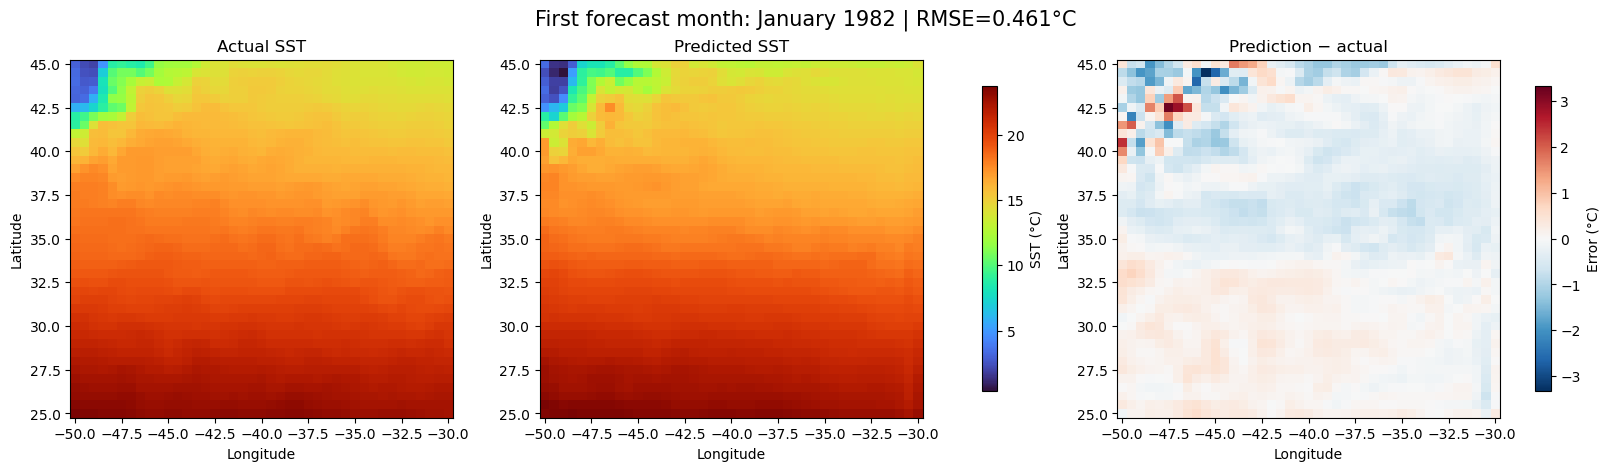

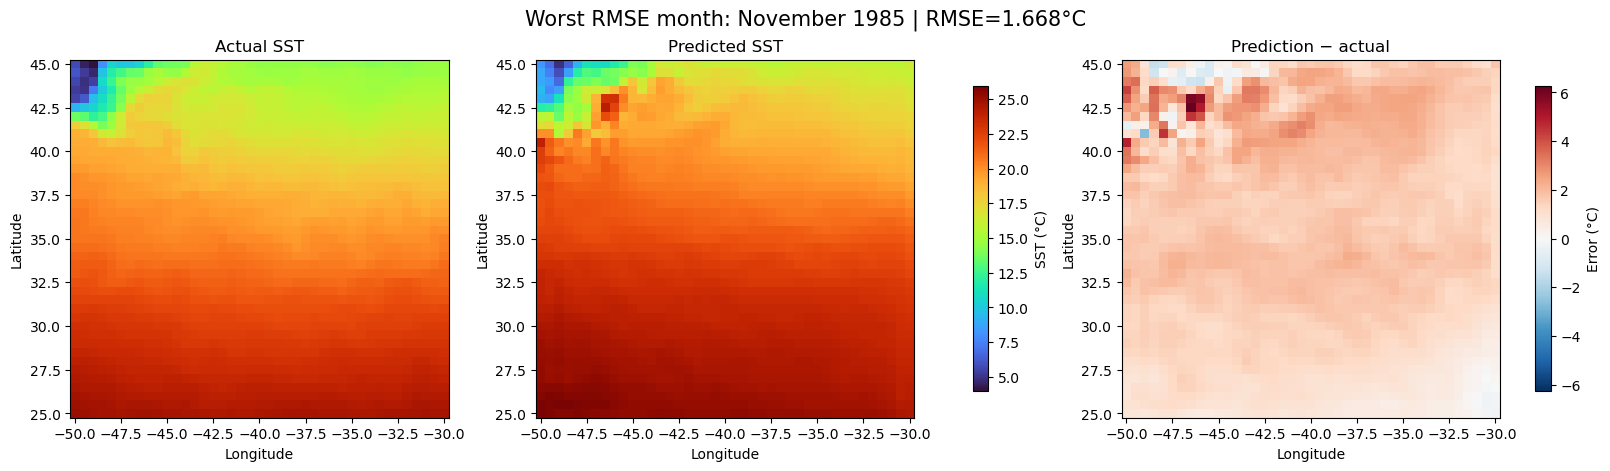

In [19]:
monthly_rmse = np.sqrt(np.nanmean((predicted_sst - actual_sst) ** 2, axis=(1, 2)))
example_index = 0
worst_index = int(np.nanargmax(monthly_rmse))

for label, index in [("First forecast month", example_index), ("Worst RMSE month", worst_index)]:
    actual_field = actual_sst[index]
    predicted_field = predicted_sst[index]
    error_field = predicted_field - actual_field
    vmin = np.nanmin([actual_field, predicted_field])
    vmax = np.nanmax([actual_field, predicted_field])
    error_max = np.nanmax(np.abs(error_field))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
    im0 = axes[0].pcolormesh(lons, lats, actual_field, shading="auto", vmin=vmin, vmax=vmax, cmap="turbo")
    im1 = axes[1].pcolormesh(lons, lats, predicted_field, shading="auto", vmin=vmin, vmax=vmax, cmap="turbo")
    im2 = axes[2].pcolormesh(
        lons, lats, error_field, shading="auto", cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-error_max, vcenter=0, vmax=error_max)
    )
    axes[0].set_title("Actual SST")
    axes[1].set_title("Predicted SST")
    axes[2].set_title("Prediction − actual")
    for ax in axes:
        ax.set(xlabel="Longitude", ylabel="Latitude")
    fig.colorbar(im0, ax=axes[:2], label="SST (°C)", shrink=0.85)
    fig.colorbar(im2, ax=axes[2], label="Error (°C)", shrink=0.85)
    fig.suptitle(
        f"{label}: {test_times[index]:%B %Y} | RMSE={monthly_rmse[index]:.3f}°C",
        fontsize=15
    )
    plt.show()

## 20. Spatial SST RMSE and bias maps

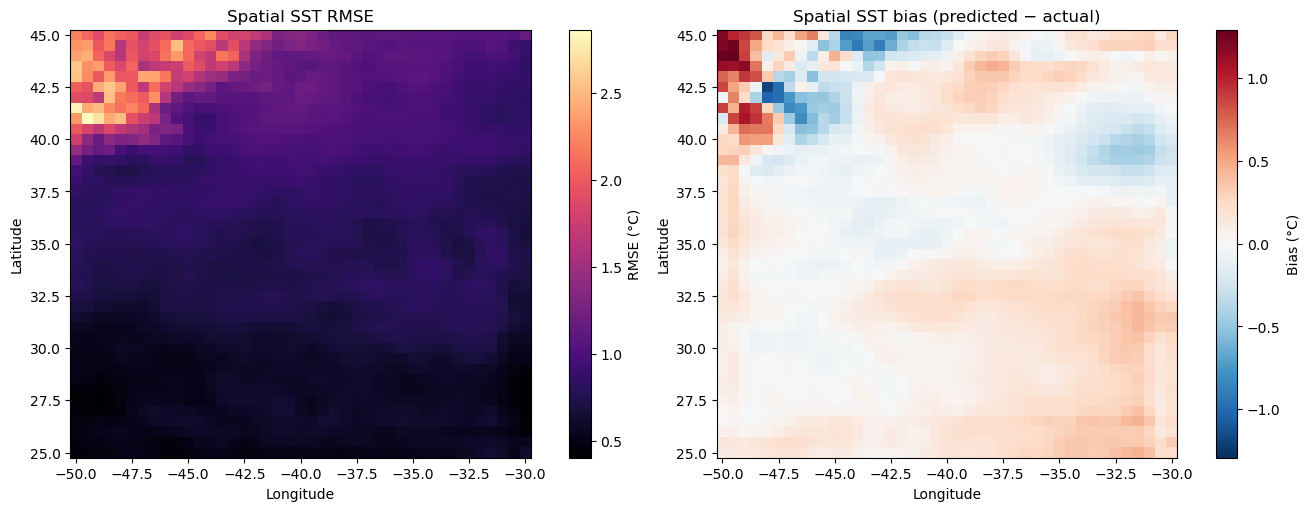

In [20]:
spatial_rmse = np.sqrt(np.nanmean((predicted_sst - actual_sst) ** 2, axis=0))
spatial_bias = np.nanmean(predicted_sst - actual_sst, axis=0)
bias_limit = np.nanmax(np.abs(spatial_bias))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
im0 = axes[0].pcolormesh(lons, lats, spatial_rmse, shading="auto", cmap="magma")
im1 = axes[1].pcolormesh(
    lons, lats, spatial_bias, shading="auto", cmap="RdBu_r",
    norm=TwoSlopeNorm(vmin=-bias_limit, vcenter=0, vmax=bias_limit)
)
axes[0].set_title("Spatial SST RMSE")
axes[1].set_title("Spatial SST bias (predicted − actual)")
for ax in axes:
    ax.set(xlabel="Longitude", ylabel="Latitude")
fig.colorbar(im0, ax=axes[0], label="RMSE (°C)")
fig.colorbar(im1, ax=axes[1], label="Bias (°C)")
plt.show()

## 21. Annual actual, predicted, and absolute-difference maps

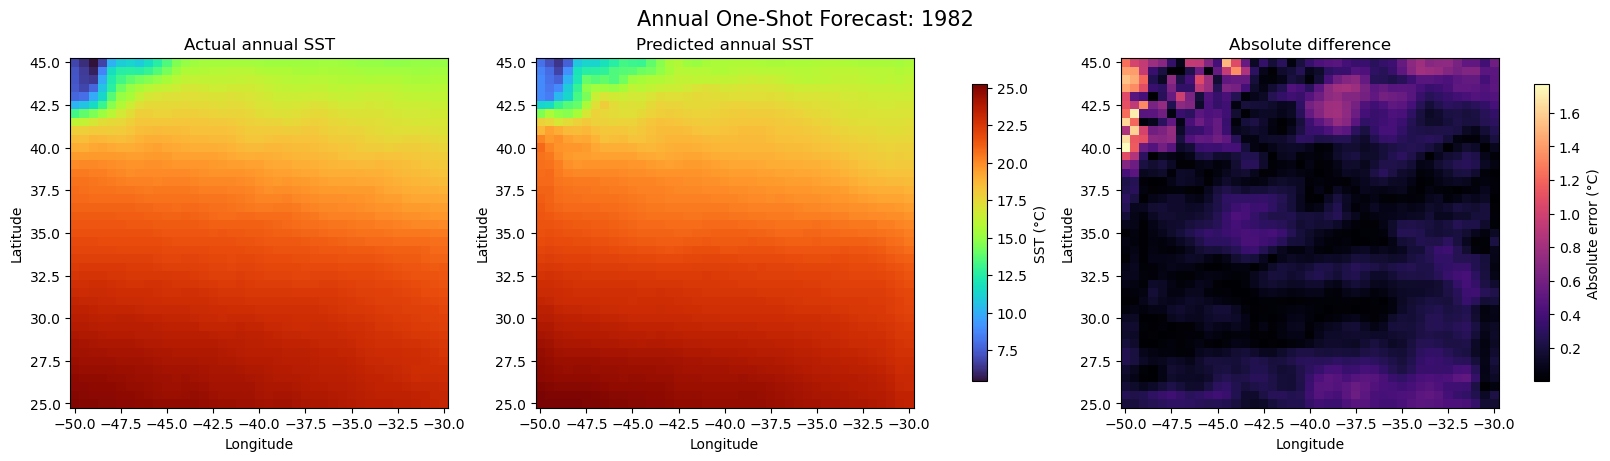

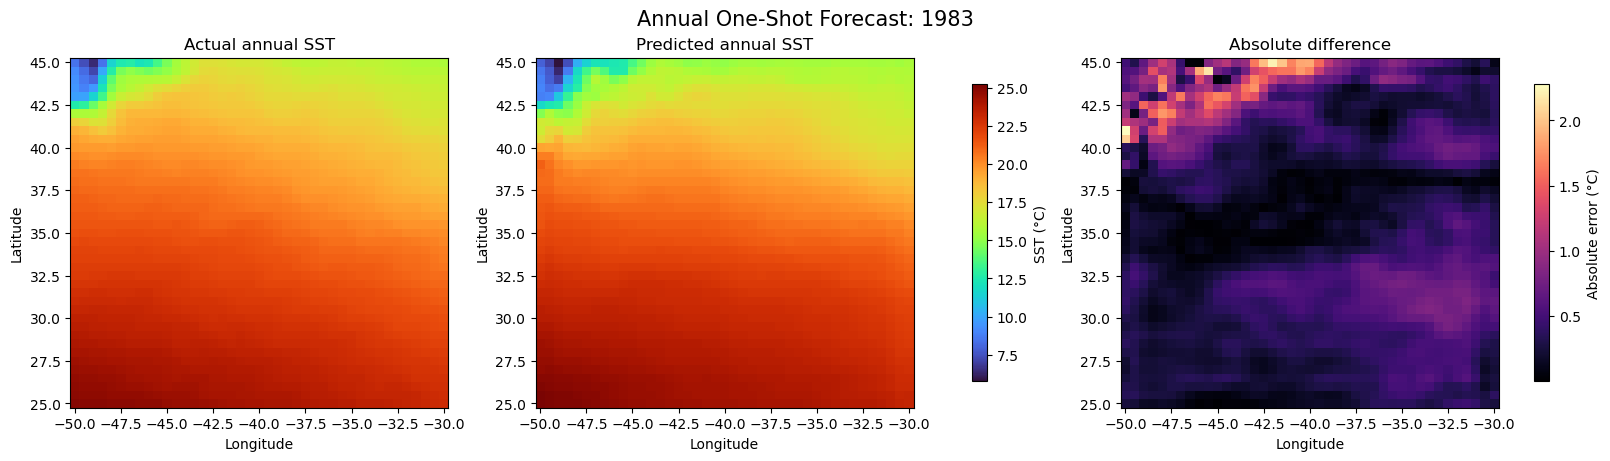

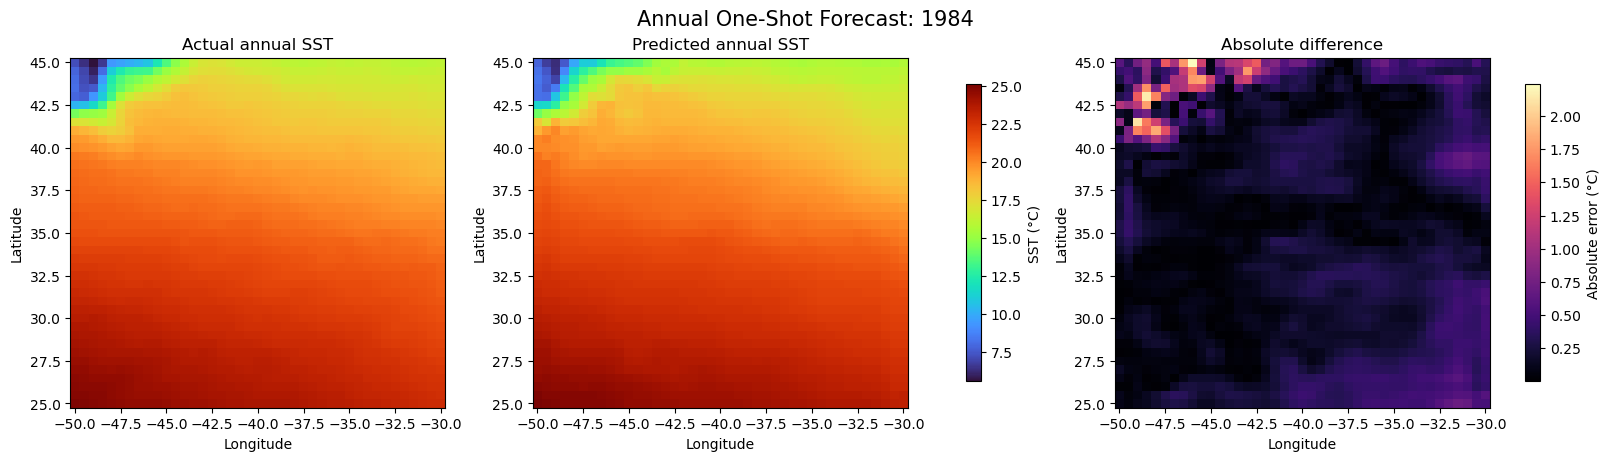

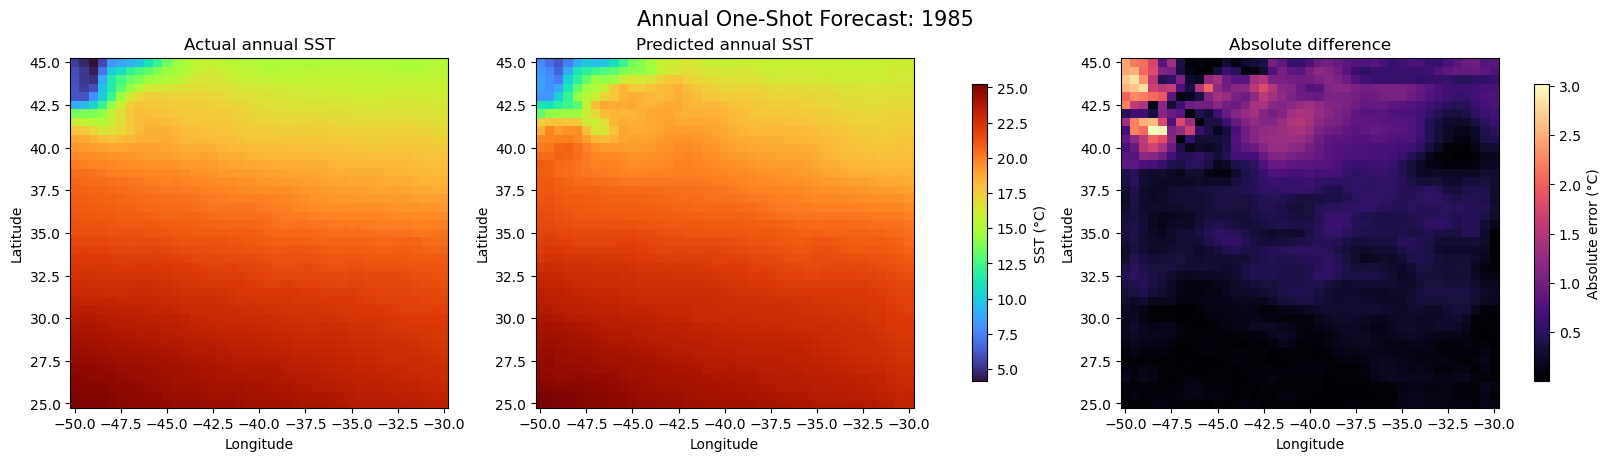

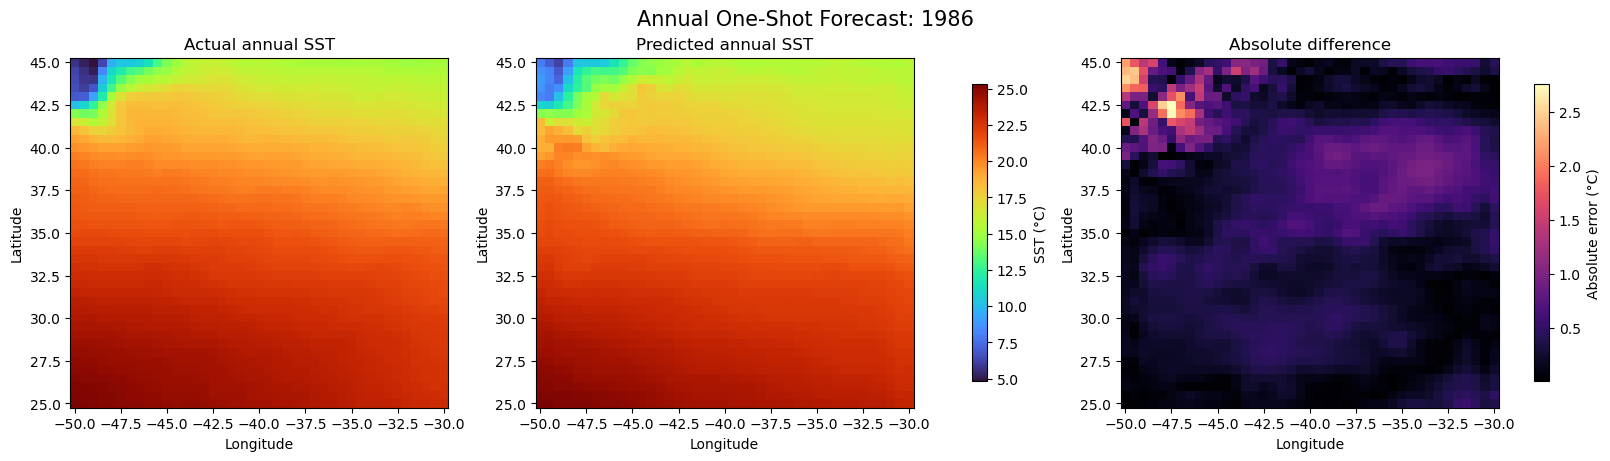

In [21]:
for block_index, year in enumerate(block_starts.year):
    actual_annual_map = np.nanmean(
        y_test_true_blocks[block_index, ..., primary_idx], axis=0
    )
    predicted_annual_map = np.nanmean(
        y_test_pred_blocks[block_index, ..., primary_idx], axis=0
    )
    absolute_difference_map = np.abs(predicted_annual_map - actual_annual_map)
    vmin = min(np.nanmin(actual_annual_map), np.nanmin(predicted_annual_map))
    vmax = max(np.nanmax(actual_annual_map), np.nanmax(predicted_annual_map))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
    im0 = axes[0].pcolormesh(lons, lats, actual_annual_map, shading="auto", cmap="turbo", vmin=vmin, vmax=vmax)
    im1 = axes[1].pcolormesh(lons, lats, predicted_annual_map, shading="auto", cmap="turbo", vmin=vmin, vmax=vmax)
    im2 = axes[2].pcolormesh(lons, lats, absolute_difference_map, shading="auto", cmap="magma")
    axes[0].set_title("Actual annual SST")
    axes[1].set_title("Predicted annual SST")
    axes[2].set_title("Absolute difference")
    for ax in axes:
        ax.set(xlabel="Longitude", ylabel="Latitude")
    fig.colorbar(im0, ax=axes[:2], label="SST (°C)", shrink=0.85)
    fig.colorbar(im2, ax=axes[2], label="Absolute error (°C)", shrink=0.85)
    fig.suptitle(f"Annual One-Shot Forecast: {year}", fontsize=15)
    plt.show()

## 22. Monthly box means for every retained feature

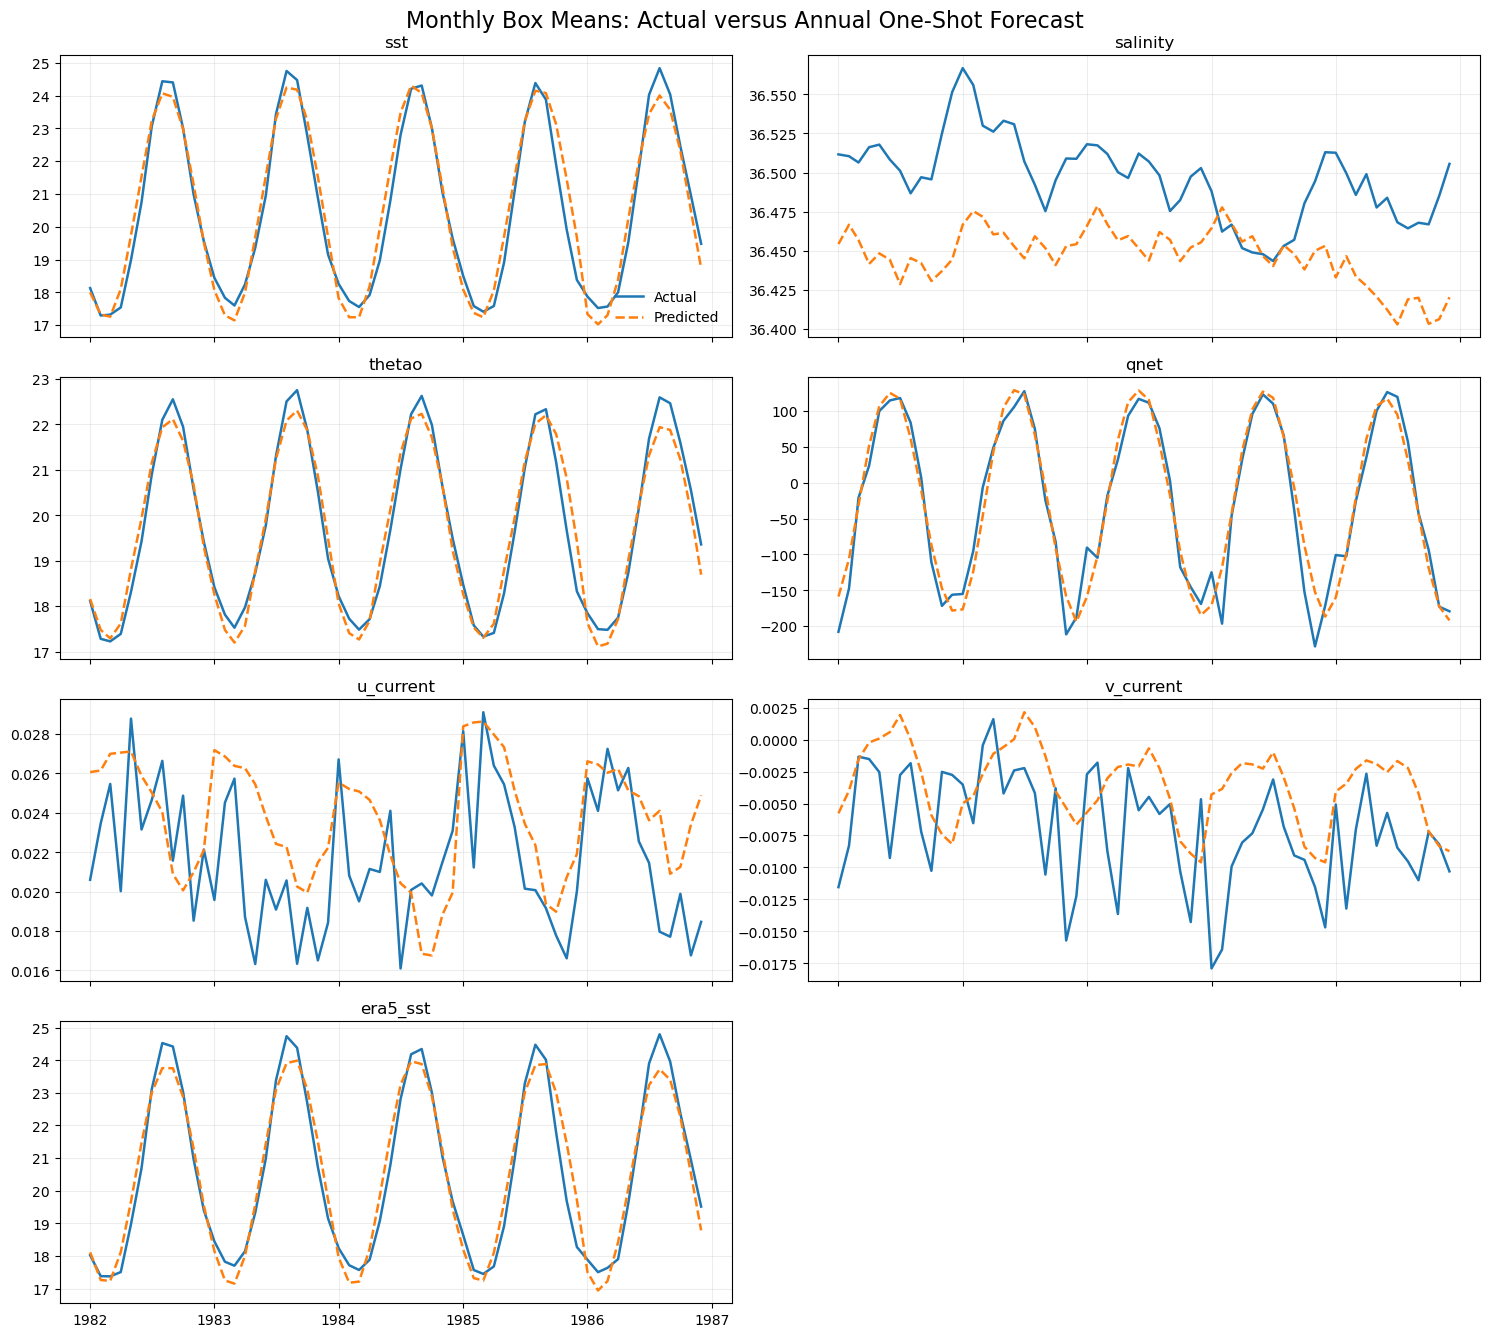

In [22]:
ncols = 2
nrows = int(np.ceil(len(features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for i, feature in enumerate(features):
    actual_mean = np.nanmean(y_test_true[..., i], axis=(1, 2))
    predicted_mean = np.nanmean(y_test_pred[..., i], axis=(1, 2))
    axes[i].plot(test_times, actual_mean, label="Actual", linewidth=1.8)
    axes[i].plot(test_times, predicted_mean, "--", label="Predicted", linewidth=1.8)
    axes[i].set_title(feature)
    axes[i].grid(alpha=0.22)

for ax in axes[len(features):]:
    ax.set_visible(False)
axes[0].legend(frameon=False)
fig.suptitle("Monthly Box Means: Actual versus Annual One-Shot Forecast", fontsize=16)
plt.tight_layout()
plt.show()

## 23. Monthly-anomaly SST performance

In [23]:
sst_climatology = monthly_climatology[..., primary_idx]
actual_anomaly = np.empty_like(actual_sst)
predicted_anomaly = np.empty_like(predicted_sst)
for i, timestamp in enumerate(test_times):
    climatology_field = sst_climatology[timestamp.month - 1]
    actual_anomaly[i] = actual_sst[i] - climatology_field
    predicted_anomaly[i] = predicted_sst[i] - climatology_field

anomaly_metrics_df = pd.DataFrame([
    metric_row(actual_anomaly, predicted_anomaly, label="SST anomaly")
]).rename(columns={"label": "field"})
display(anomaly_metrics_df)

,field,n,MAE,RMSE,R2,bias_predicted_minus_actual,Pearson_r
0,SST anomaly,100860,0.691196,0.93914,-0.703614,0.078439,0.250211


## 24. Save metrics and predictions

In [24]:
tables = {
    "feature_metrics": overall_metrics_df,
    "baseline_metrics": baseline_metrics_df,
    "sst_lead_metrics": lead_metrics_df,
    "sst_yearly_metrics": yearly_metrics_df,
    "sst_cumulative_metrics": cumulative_metrics_df,
    "annual_sst_comparison": annual_comparison_df,
    "annual_relative_difference": annual_relative_difference_df,
    "annual_histograms": annual_histogram_summary_df,
    "sst_anomaly_metrics": anomaly_metrics_df,
}
for name, table in tables.items():
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

predictions_ds = xr.Dataset(
    data_vars={
        "actual": (("time", "lat", "lon", "feature"), y_test_true.astype(np.float32)),
        "predicted": (("time", "lat", "lon", "feature"), y_test_pred.astype(np.float32)),
        "error": (("time", "lat", "lon", "feature"), (y_test_pred - y_test_true).astype(np.float32)),
    },
    coords={
        "time": test_times,
        "lat": lats,
        "lon": lons,
        "feature": features,
    },
    attrs={
        "method": "Iarla-style direct 12-month one-shot ConvLSTM",
        "evaluation": "Five independent calendar-year blocks initialized from observed prior years",
        "lookback_months": LOOKBACK,
        "forecast_horizon_months": HORIZON,
    },
)
netcdf_path = OUTPUT_DIR / "iarla_oneshot_predictions_1982_1986.nc"
encoding = {
    name: {"zlib": True, "complevel": 4, "dtype": "float32"}
    for name in predictions_ds.data_vars
}
predictions_ds.to_netcdf(netcdf_path, engine="h5netcdf", encoding=encoding)

print("Saved model:", MODEL_PATH)
print("Saved scaler:", SCALER_PATH)
print("Saved predictions:", netcdf_path)
print("Saved tables:", OUTPUT_DIR)

Saved model: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month\best_iarla_oneshot_convlstm.keras
Saved scaler: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month\iarla_oneshot_scaler.pkl
Saved predictions: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month\iarla_oneshot_predictions_1982_1986.nc
Saved tables: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\Iarla_OneShot_12Month
